In [116]:
import torch
import torch_geometric as pyg
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv

from torch_geometric.loader import DataLoader
from torch_geometric.datasets import Planetoid
device = "cuda" if torch.cuda.is_available() else "cpu"
dataset_name ="Cora"

In [117]:
transform = T.Compose([T.NormalizeFeatures(),T.ToUndirected(),T.AddSelfLoops()])
dataset = Planetoid(root=f'/tmp/{dataset_name}',name=dataset_name,transform=transform)

In [118]:
print(f"Dataset length: {len(dataset)}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Number of features: {dataset.num_node_features}")

data = dataset[0]
print(f"Dataset information: {data}")
loader = DataLoader(dataset=dataset,batch_size=32,shuffle=True)
print(f"Dataloader Information: {loader}")
print("Batch information:")
for batch in loader:
    print(f"DataBatch : {batch}")

Dataset length: 1
Number of classes: 7
Number of features: 1433
Dataset information: Data(x=[2708, 1433], edge_index=[2, 13264], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Dataloader Information: <torch_geometric.loader.dataloader.DataLoader object at 0x0000020CA94E00D0>
Batch information:
DataBatch : DataBatch(x=[2708, 1433], edge_index=[2, 13264], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], batch=[2708], ptr=[2])


In [119]:
class GCN(torch.nn.Module):
    def __init__(self,out_indices):
        super().__init__()
        self.n = len(out_indices)-1
        self.gcn_layers = torch.nn.ModuleList([GCNConv(out_indices[i],out_indices[i+1]) for i in range(self.n)])
        self.dropout = torch.nn.Dropout(p=0.5)
        self.relu = torch.nn.ReLU()
    
    def forward(self,dataset):
        x,edge_index = dataset.x,dataset.edge_index
        for i in range(self.n):
            x = self.gcn_layers[i](x,edge_index)
            x = self.relu(x)
            x = self.dropout(x)
        return torch.nn.functional.log_softmax(x,dim=-1)

In [120]:
model = GCN([dataset.num_node_features,256,dataset.num_classes]).to(device)
data = dataset[0].to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()
epochs = 2000

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 200
counter = 0
for i in range(epochs):
    model.train()
    optimizer.zero_grad()
    out=model(data)
    loss = criterion(out[data.train_mask],data.y[data.train_mask])
    loss.backward()
    optimizer.step()


    model.eval()
    with torch.no_grad():
        val_loss = criterion(out[data.val_mask],data.y[data.val_mask])
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        if(val_loss<best_val_loss):
            best_val_loss = val_loss
            torch.save(model.state_dict(),"best_gcn.pickle")
            counter = 0
        else:
            counter +=1
    if i==0 or i%20==19:
        print(f"Epoch {i} of {epochs}, Train loss: {loss}. Validation loss: {val_loss}")
    if counter>patience:
        break


Epoch 0 of 2000, Train loss: 1.9450221061706543. Validation loss: 1.9457273483276367
Epoch 19 of 2000, Train loss: 1.8953160047531128. Validation loss: 1.914293646812439
Epoch 39 of 2000, Train loss: 1.8000857830047607. Validation loss: 1.873384952545166
Epoch 59 of 2000, Train loss: 1.6840686798095703. Validation loss: 1.8059568405151367
Epoch 79 of 2000, Train loss: 1.5766466856002808. Validation loss: 1.7211073637008667
Epoch 99 of 2000, Train loss: 1.516833782196045. Validation loss: 1.641981840133667
Epoch 119 of 2000, Train loss: 1.3731623888015747. Validation loss: 1.628061294555664
Epoch 139 of 2000, Train loss: 1.3515795469284058. Validation loss: 1.5718930959701538
Epoch 159 of 2000, Train loss: 1.3080891370773315. Validation loss: 1.5620561838150024
Epoch 179 of 2000, Train loss: 1.2706501483917236. Validation loss: 1.524337649345398
Epoch 199 of 2000, Train loss: 1.251554250717163. Validation loss: 1.4899781942367554
Epoch 219 of 2000, Train loss: 1.1480308771133423. Valida

In [121]:
model.load_state_dict(torch.load("best_gcn.pickle",weights_only=True))

model.eval()
with torch.no_grad():
    out = model(data)
    y_pred = torch.argmax(out,dim=-1)
    accuracy = (y_pred[data.test_mask]==data.y[data.test_mask]).sum().item()/data.test_mask.sum().item()
    loss = criterion(out,data.y)
    print(f"Final test loss: {loss}, accuracy: {accuracy}")

Final test loss: 1.2064725160598755, accuracy: 0.812


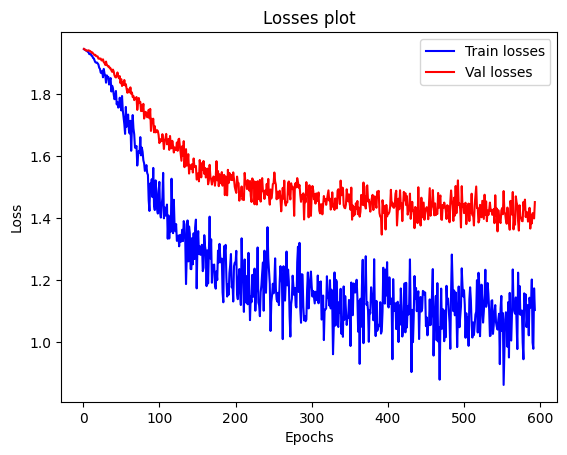

In [122]:
import matplotlib.pyplot as plt

total = len(train_losses)
x_val = range(1,total+1)
plt.title("Losses plot")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(x_val,train_losses,label="Train losses",color='blue')
plt.plot(x_val,val_losses,label="Val losses",color="red")
plt.legend()
plt.show()

In [123]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

@torch.no_grad()
def get_predictions():
    model.eval()
    out = model(data)
    pred = torch.argmax(out,dim=1)
    
    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()

    return y_true,y_pred

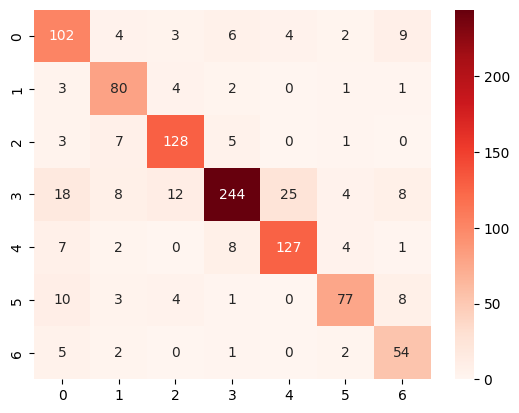

In [127]:
y_true,y_pred = get_predictions()

cm = confusion_matrix(y_true,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',xticklabels=range(dataset.num_classes),yticklabels=range(dataset.num_classes))
plt.show()